# Ce abundances in the halo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import paths
from utils import get_bin_centers, binned_quantiles, apply_alpha_cut
from plotting import get_color_list
from mwm_sample import abundance_ratio

plt.style.use(paths.styles / 'notebook.mplstyle')

In [2]:
mwm_rgb = pd.read_csv(paths.data / 'MWM' / 'MWM_RGB.csv')
mwm_rgb

/var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_67130/610113364.py:1: DtypeWarning: Columns (44) have mixed types. Specify dtype option on import or set low_memory=False.
  mwm_rgb = pd.read_csv(paths.data / 'MWM' / 'MWM_RGB.csv')



,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,phot_rp_mean_mag,ruwe,z_max,Rg,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr
0,54381405,NaN,421506067509558016,421506067510359808,369831290,16384,tic_v8,25,27021597850724078,4291440182,...,11.174816,1.058355,NaN,NaN,-0.325526,0.017186,0.000862,-0.000862,0.343573,0.342712
1,54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,...,10.450673,1.183852,0.205899,8.531358,-0.263113,0.010890,-0.013271,0.013271,0.260731,0.274003
2,54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,...,10.509450,1.051452,0.107297,8.766076,-0.241018,0.079030,0.003839,-0.003839,0.323887,0.320048
3,54381968,2M00220667+5639444,421558740986710784,421558740986710784,403316795,16025,gaia_dr3_source,31,63050394783222492,4291878364,...,13.976727,1.005231,NaN,NaN,-0.112523,0.228345,-0.020530,0.020530,0.320339,0.340869
4,54381984,2M00223542+5645497,421560390254274304,421560390254274304,403393131,16025,gaia_dr3_source,31,63050394783223054,4291881586,...,10.972714,0.981112,0.178598,8.755011,0.061913,0.190950,0.048523,-0.048523,0.177560,0.129037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176718,129060852,2M09102693-4801480,5326834219657160960,5326834219657160960,355667744,171467,gaia_dr3_source,31,63050395876140056,5802252790,...,NaN,NaN,NaN,NaN,-0.451700,-0.091048,0.024848,-0.024848,0.385501,0.360653
176719,129060869,2M13544004-6145050,5867067884895910016,5867067884895910016,381878669,184774,gaia_dr3_source,31,63050396109299295,5632215191,...,NaN,NaN,NaN,NaN,0.251323,0.168338,0.085263,-0.085263,0.002278,-0.082985
176720,129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,...,NaN,NaN,NaN,NaN,-0.363648,-0.118817,-0.011611,0.011611,0.233220,0.244831
176721,129060885,2M08333243-3911278,5529360241405866752,5529360241405866752,185021879,160694,gaia_dr3_source,31,63050395950945615,5800869040,...,NaN,NaN,NaN,NaN,-0.176592,0.063355,-0.014382,0.014382,0.225565,0.239947


In [77]:
# Impose higher S/N, upper limits from Shetrone et al. (2025)
def ce_upper_limit(teff, snr):
    return -0.93 + 0.51*(teff/1000) - 1.84*(np.log10(snr)) + 0.174*(np.log10(snr))**2

mwm_rgb = mwm_rgb[
    (mwm_rgb['snr'] > 150) &
    (mwm_rgb['ce_h'] - mwm_rgb['e_ce_h'] > ce_upper_limit(mwm_rgb['teff'], mwm_rgb['snr']))
].copy()

In [78]:
mwm_rgb['ce_mn'], mwm_rgb['e_ce_mn'] = abundance_ratio(mwm_rgb, 'ce', 'mn')
mwm_rgb['mg_mn'], mwm_rgb['e_mg_mn'] = abundance_ratio(mwm_rgb, 'mg', 'mn')
mwm_rgb['al_fe'], mwm_rgb['e_al_fe'] = abundance_ratio(mwm_rgb, 'al', 'fe')

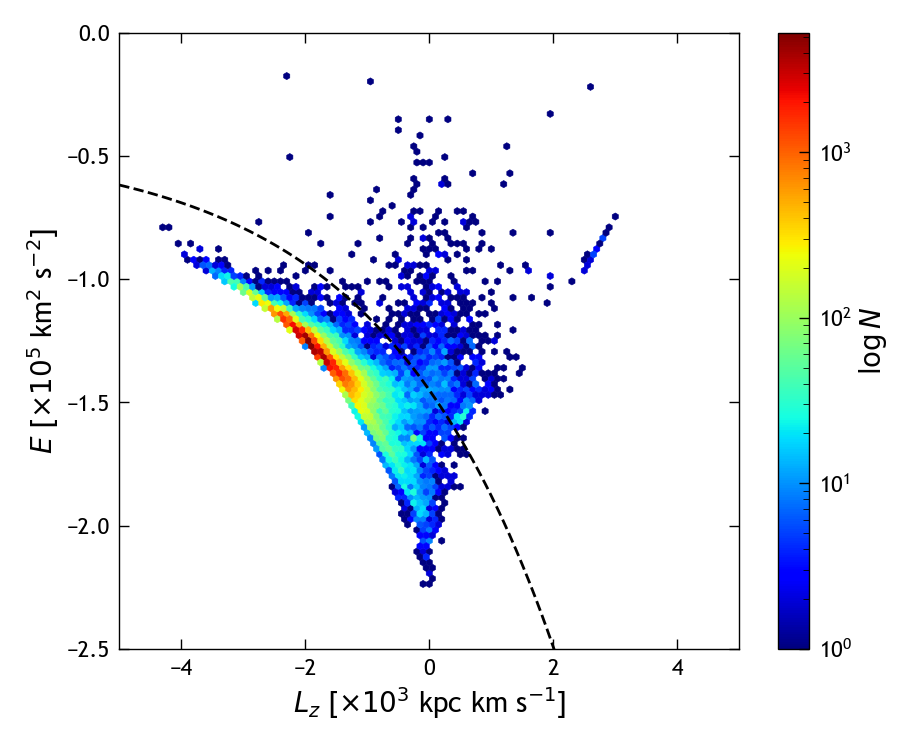

In [79]:
fig, ax = plt.subplots(figsize=(5, 4))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-5, 5, -2.5, 0.])
pcm = ax.hexbin(
    mwm_rgb['Lz']/1e3, mwm_rgb['E']/1e5, 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=np.sum,
    norm=LogNorm(),
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

def halo_ELz_cut(Lz):
    # return -0.035*(Lz + 5)**2 - 0.7
    return -0.45 - np.exp(Lz / 2.8)

Lz_arr = np.arange(-5, 5.1, 0.1)
ax.plot(Lz_arr, halo_ELz_cut(Lz_arr), 'k--')

ax.set_xlabel(r'$L_z$ [$\times10^3$ kpc km s$^{-1}$]')
ax.set_ylabel(r'$E$ [$\times 10^5$ km$^2$ s$^{-2}$]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])

plt.show()

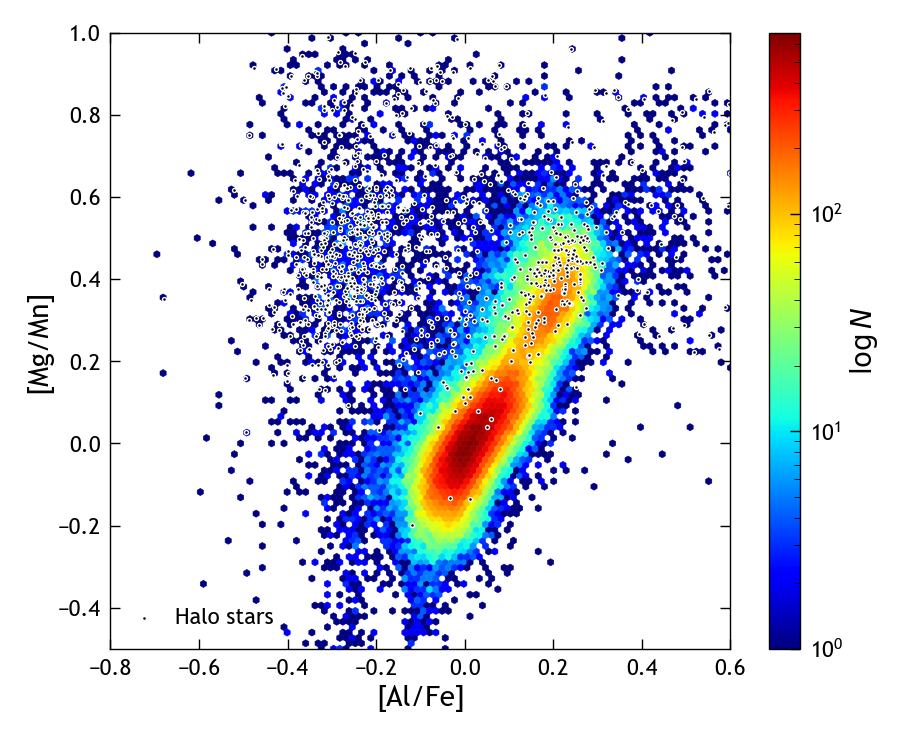

In [80]:
fig, ax = plt.subplots(figsize=(5, 4))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-0.8, 0.6, -0.5, 1])
pcm = ax.hexbin(
    mwm_rgb['al_fe'], mwm_rgb['mg_mn'], 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=np.sum,
    norm=LogNorm(),
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

mwm_halo = mwm_rgb[mwm_rgb['E']/1e5 > halo_ELz_cut(mwm_rgb['Lz']/1e3)]
ax.scatter(mwm_halo['al_fe'], mwm_halo['mg_mn'], rasterized=True, edgecolors='w', linewidths=0.5, s=2, c='k', label='Halo stars')

ax.set_xlabel('[Al/Fe]')
ax.set_ylabel('[Mg/Mn]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

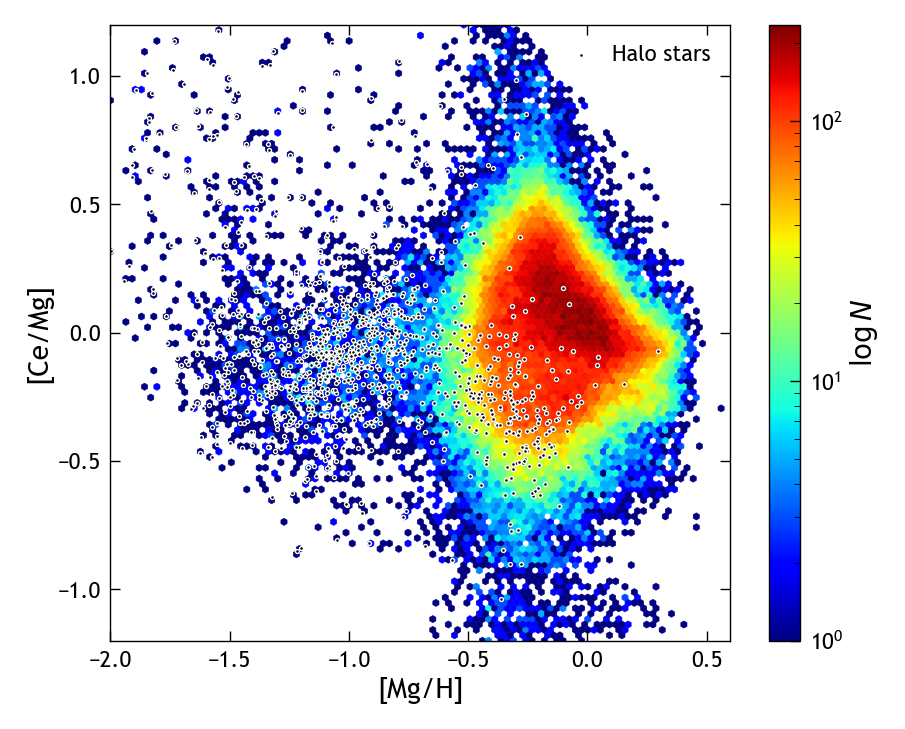

In [87]:
fig, ax = plt.subplots(figsize=(5, 4))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-2., 0.6, -1.2, 1.2])
pcm = ax.hexbin(
    mwm_rgb['mg_h'], mwm_rgb['ce_mg'], 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=np.sum,
    norm=LogNorm(),
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

ax.scatter(mwm_halo['mg_h'], mwm_halo['ce_mg'], rasterized=True, edgecolors='w', linewidths=0.5, s=2, c='k', label='Halo stars')

ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

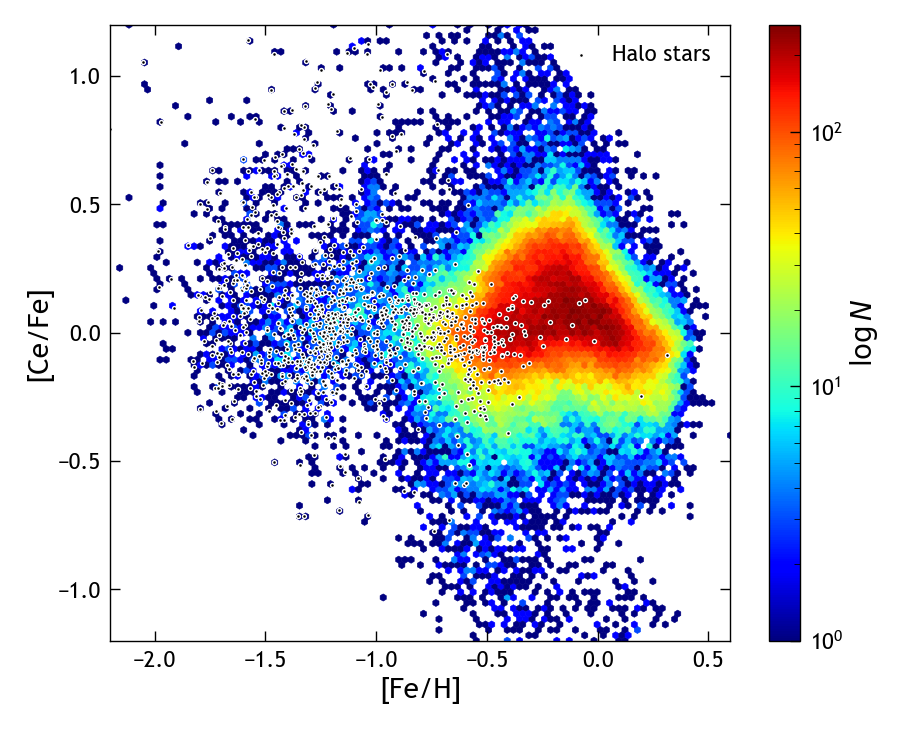

In [88]:
fig, ax = plt.subplots(figsize=(5, 4))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-2.2, 0.6, -1.2, 1.2])
pcm = ax.hexbin(
    mwm_rgb['fe_h'], mwm_rgb['ce_fe'], 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=np.sum,
    norm=LogNorm(),
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

ax.scatter(mwm_halo['fe_h'], mwm_halo['ce_fe'], rasterized=True, edgecolors='w', linewidths=0.5, s=2, c='k', label='Halo stars')

ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Ce/Fe]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

Can I select halo stars that aren't in LMC, SMC, or other dwarfs? Could also try to exclude GSE.